In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [35]:
df=pd.read_csv("processed_digital_burnout_dataset.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'processed_digital_burnout_dataset.csv'

In [ ]:
df.columns

Index(['user_id', 'age', 'occupation', 'work_mode', 'device_usage_type',
       'daily_screen_time', 'social_media_hours', 'doomscrolling_duration',
       'app_switch_frequency', 'notification_count', 'smartphone_unlocks',
       'late_night_device_usage', 'focus_sessions', 'deep_work_hours',
       'distraction_frequency', 'task_completion_rate', 'concentration_score',
       'sleep_hours', 'sleep_quality', 'caffeine_intake', 'physical_activity',
       'stress_level', 'workspace_quality', 'meeting_hours',
       'internet_stability', 'remote_work_days', 'motivation_level',
       'mental_fatigue', 'emotional_exhaustion', 'work_satisfaction',
       'mental_state', 'burnout_risk', 'productivity_score',
       'productivity_category'],
      dtype='object')

In [ ]:
df.corr()["productivity_score"].sort_values(ascending=False)

productivity_score         1.000000
deep_work_hours            0.500044
task_completion_rate       0.355764
concentration_score        0.347326
focus_sessions             0.230093
workspace_quality          0.172281
motivation_level           0.128205
work_satisfaction          0.090537
mental_state               0.073689
physical_activity          0.040005
sleep_hours                0.038546
caffeine_intake            0.000810
internet_stability         0.000613
mental_fatigue             0.000603
device_usage_type          0.000396
occupation                 0.000274
remote_work_days           0.000153
smartphone_unlocks         0.000110
sleep_quality              0.000047
meeting_hours             -0.000468
work_mode                 -0.000482
user_id                   -0.000645
age                       -0.001348
notification_count        -0.033855
distraction_frequency     -0.054059
late_night_device_usage   -0.055803
doomscrolling_duration    -0.071542
daily_screen_time         -0

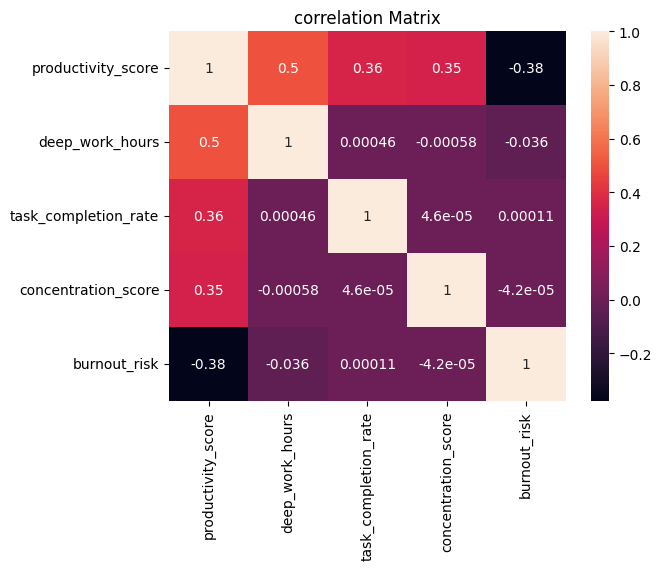

In [36]:
import seaborn as sns

plt.title("correlation Matrix")
sns.heatmap(df[["productivity_score","deep_work_hours","task_completion_rate","concentration_score","burnout_risk",]].corr(), annot=True)
plt.savefig("heatmap.png")
plt.show()

In [37]:
#preparing data for sleep_hours vs productivity_score
df_sleep= pd.DataFrame(columns=["sleep_hours", "avg_prod"])

for i in df["sleep_hours"].unique():
    avg = df[df["sleep_hours"] == i]["productivity_score"].mean()

    df_sleep.loc[len(df_sleep)] = [i, avg]

df_sleep

,sleep_hours,avg_prod
0,30.0,71.065983
1,27.0,70.824836
2,26.0,70.787815
3,32.0,71.172963
4,50.0,72.439338
...,...,...
67,66.0,73.509420
68,11.0,69.588232
69,65.0,73.285821
70,68.0,73.780688


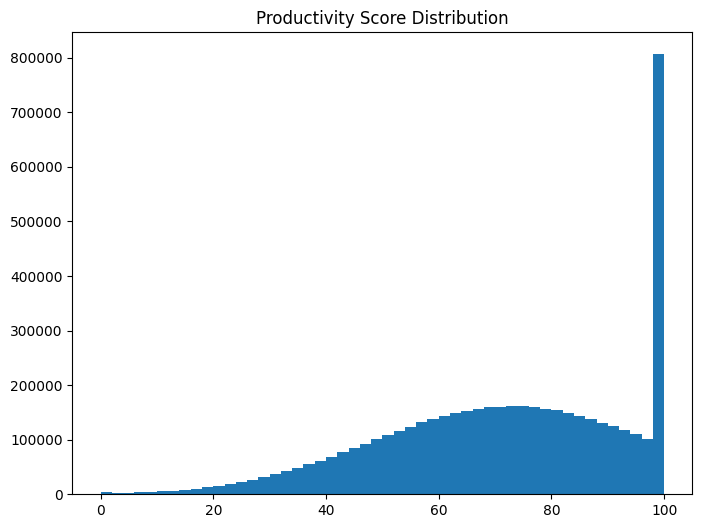

In [38]:
plt.figure(figsize=(8,6))

plt.hist(
    df["productivity_score"],
    bins=50
)

plt.title("Productivity Score Distribution")
plt.savefig("Productivity_Score.png")
plt.show()

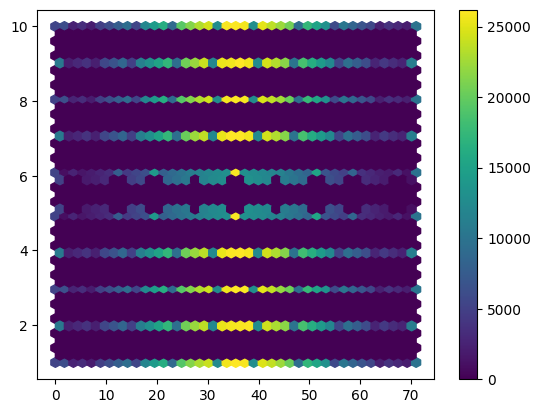

In [39]:
plt.hexbin(
    df["sleep_hours"],
    df["concentration_score"],
    gridsize=40
)

plt.colorbar()
plt.savefig("hex.png")
plt.show()

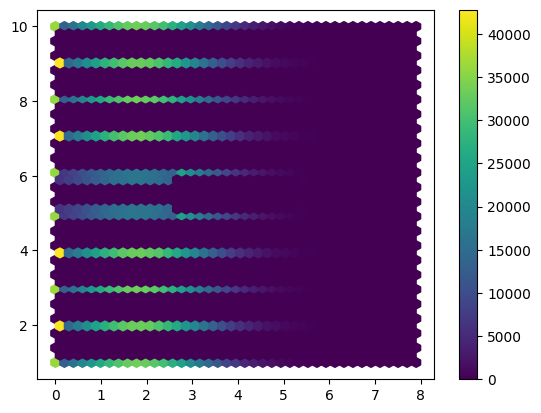

In [40]:
plt.hexbin(
    df["doomscrolling_duration"],
    df["stress_level"],
    gridsize=40
)

plt.colorbar()
plt.show()

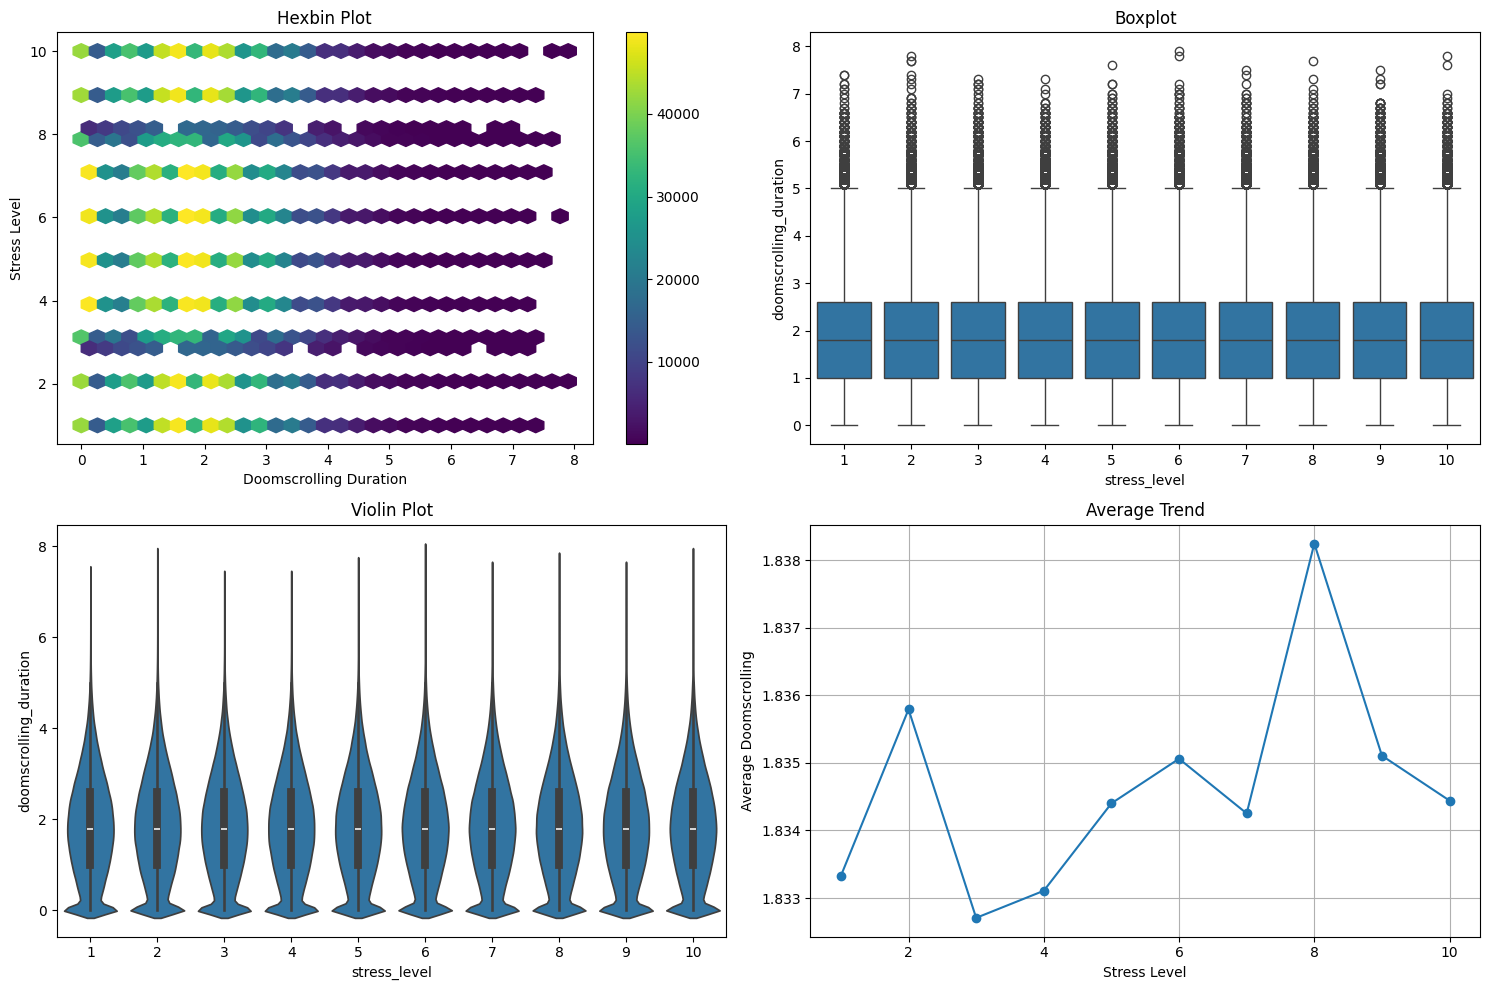

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(2, 2, figsize=(15,10))

# 1. Hexbin
hb = ax[0,0].hexbin(
    df["doomscrolling_duration"],
    df["stress_level"],
    gridsize=30,
    cmap="viridis",
    mincnt=1
)

fig.colorbar(hb, ax=ax[0,0])

ax[0,0].set_title("Hexbin Plot")
ax[0,0].set_xlabel("Doomscrolling Duration")
ax[0,0].set_ylabel("Stress Level")


# 2. Boxplot
sns.boxplot(
    x=df["stress_level"],
    y=df["doomscrolling_duration"],
    ax=ax[0,1]
)

ax[0,1].set_title("Boxplot")


# 3. Violin Plot
sns.violinplot(
    x=df["stress_level"],
    y=df["doomscrolling_duration"],
    ax=ax[1,0]
)

ax[1,0].set_title("Violin Plot")


# 4. Average Trend Line
avg = df.groupby("stress_level")["doomscrolling_duration"].mean()

ax[1,1].plot(
    avg.index,
    avg.values,
    marker='o'
)

ax[1,1].set_title("Average Trend")
ax[1,1].set_xlabel("Stress Level")
ax[1,1].set_ylabel("Average Doomscrolling")

ax[1,1].grid(True)

plt.tight_layout()
plt.savefig("group.png")
plt.show()

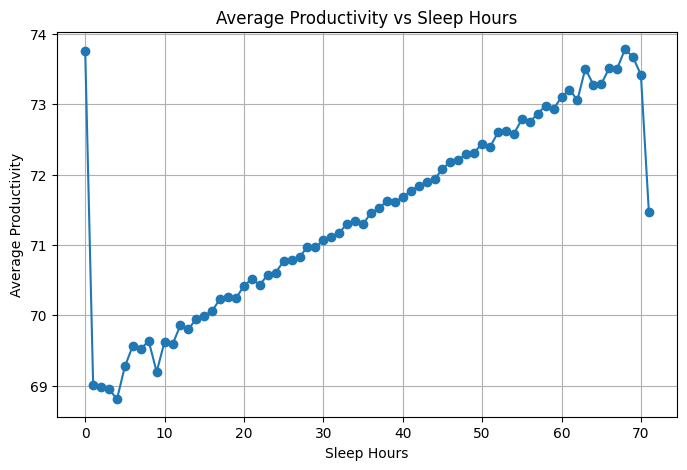

In [42]:
avg = df.groupby("sleep_hours")["productivity_score"].mean()

plt.figure(figsize=(8,5))

plt.plot(avg.index, avg.values, marker='o')

plt.xlabel("Sleep Hours")
plt.ylabel("Average Productivity")
plt.title("Average Productivity vs Sleep Hours")

plt.grid(True)
plt.savefig("avg_prod_sleep.png")
plt.show()

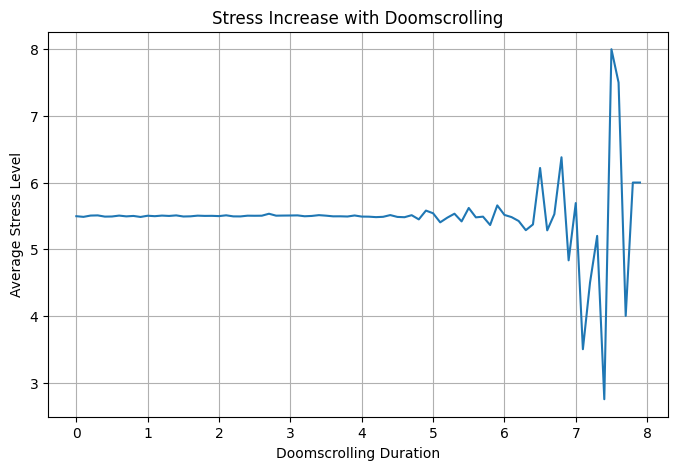

In [43]:
avg = df.groupby("doomscrolling_duration")["stress_level"].mean()

plt.figure(figsize=(8,5))

plt.plot(avg.index, avg.values)

plt.xlabel("Doomscrolling Duration")
plt.ylabel("Average Stress Level")
plt.title("Stress Increase with Doomscrolling")

plt.grid(True)
plt.savefig("stress.png")
plt.show()

C:\Users\manoh\AppData\Local\Temp\ipykernel_11780\838506346.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg = df.groupby(bins)["productivity_score"].mean()


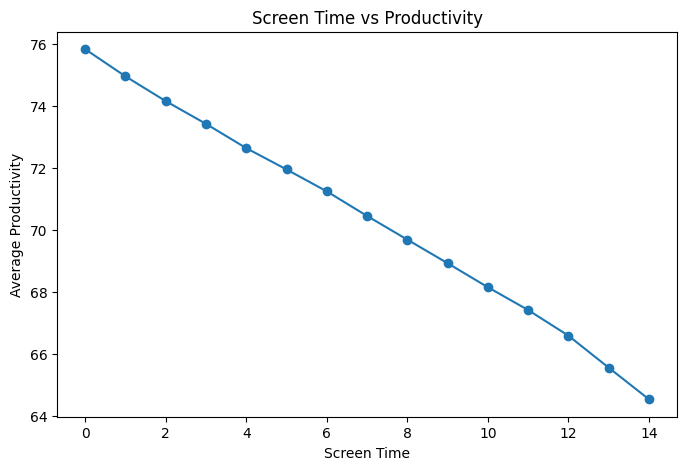

In [44]:
bins = pd.cut(df["daily_screen_time"], bins=15)

avg = df.groupby(bins)["productivity_score"].mean()

plt.figure(figsize=(8,5))
plt.plot(avg.values, marker='o')

plt.title("Screen Time vs Productivity")
plt.xlabel("Screen Time")
plt.ylabel("Average Productivity")
plt.savefig("screentime.png")
plt.show()